                                     Retail Sales and Profitability Analysis

    --Objective--
This project analyzes a retail sales dataset containing 9,994 records, including information about orders, customers, products, regions, sales, profit, and discounts. The aim of this analysis is to explore the dataset using Python in order to understand overall sales performance, identify the most and least profitable product categories, compare regional results, and examine how discount levels affect profit.

By cleaning and analyzing the data using Python libraries such as Pandas and visualization tools, this project demonstrates how exploratory data analysis can be used to extract meaningful insights from raw data and support business decision-making.

# Import necessary libraries

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Data Loading and initial overview

In [55]:
df = pd.read_csv("Superstore.2.csv")

In [57]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2011-110422,22-01-2011,24-01-2011,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.25,3,0.20,4.10
9990,9991,CA-2014-121258,27-02-2014,04-03-2014,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.96,2,0.00,15.63
9991,9992,CA-2014-121258,27-02-2014,04-03-2014,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.58,2,0.20,19.39
9992,9993,CA-2014-121258,27-02-2014,04-03-2014,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.60,4,0.00,13.32


In [58]:
df.describe(include='O')

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,1238,1334,4,793,793,3,1,531,49,4,1862,3,17,1841
top,CA-2014-100111,06-09-2013,16-12-2012,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staples
freq,14,38,35,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,227


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

# Data Pre-processing

--checking null-values--

In [60]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

--Dropped unnecessary columns and duplicates--

In [61]:
df.drop("Row ID",axis=1,inplace=True)
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [62]:
df = df.drop_duplicates()
df.shape

(9993, 20)

--Converted Order Date and Ship Date columns to proper datetime format--

In [64]:
df['Order Date'] = pd.to_datetime(df['Order Date'],dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'],dayfirst=True)

--Created columns for Year,Month,and Month Name--

In [66]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%b')
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name
0,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,2013,11,Nov
1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,2013,11,Nov
2,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,2013,6,Jun
3,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,2012,10,Oct
4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,2012,10,Oct


EXPLORATORY DATA ANALYSIS

In [67]:
print("Total Sales:") ,df['Sales'].sum()

Total Sales:


(None, np.float64(2296919.6999999997))

In [68]:
print("Average Profit:") ,df['Profit'].mean()

Average Profit:


(None, np.float64(28.661047733413387))

In [69]:
print("Net Profit:"), df['Profit'].sum()

Net Profit:


(None, np.float64(286409.85))

In [71]:
df[['Discount', 'Profit']].corr()

,Discount,Profit
Discount,1.000000,-0.219481
Profit,-0.219481,1.000000


In [72]:
df["Category"].value_counts()

Category
Office Supplies    6026
Furniture          2120
Technology         1847
Name: count, dtype: int64

In [73]:
df["Region"].value_counts()

Region
West       3203
East       2847
Central    2323
South      1620
Name: count, dtype: int64

In [74]:
print("Sales by Category")
category_sales = df.groupby("Category")["Sales"].sum()
category_sales

Sales by Category


Category
Furniture          741718.61
Office Supplies    719046.99
Technology         836154.10
Name: Sales, dtype: float64

In [76]:
print("Profit by Category")
category_profit = df.groupby("Category")["Profit"].sum()
category_profit

Profit by Category


Category
Furniture           18463.31
Office Supplies    122490.88
Technology         145455.66
Name: Profit, dtype: float64

In [79]:
print("Total Sales by Region")
region_sales = df.groupby("Region")["Sales"].sum()
region_sales

Total Sales by Region


Region
Central    501239.88
East       678499.99
South      391721.90
West       725457.93
Name: Sales, dtype: float64

In [80]:
print("Profit by Region")
region_profit = df.groupby("Region")["Profit"].sum()
region_profit

Profit by Region


Region
Central     39706.45
East        91534.90
South       46749.71
West       108418.79
Name: Profit, dtype: float64

In [81]:
pivot_sales = pd.pivot_table(df,
                             values="Sales",
                             index="Category",
                             columns="Region",
                             aggfunc="sum")

pivot_sales

Region,Central,East,South,West
Category,,,,
Furniture,163797.26,208009.80,117298.68,252612.87
Office Supplies,167026.33,205516.15,125651.31,220853.20
Technology,170416.29,264974.04,148771.91,251991.86


In [82]:
pivot_profit = pd.pivot_table(df,
                              values="Profit",
                              index="Segment",
                              columns="Category",
                              aggfunc="sum")

pivot_profit

Category,Furniture,Office Supplies,Technology
Segment,,,
Consumer,6990.95,56330.27,70798.11
Corporate,7584.91,40227.33,44167.21
Home Office,3887.45,25933.28,30490.34


In [83]:
correlation_matrix = df.corr(numeric_only=True)
correlation_matrix

,Postal Code,Sales,Quantity,Discount,Profit,Year,Month
Postal Code,1.000000,-0.023851,0.012731,0.058471,-0.029968,0.004482,0.024586
Sales,-0.023851,1.000000,0.200808,-0.028197,0.479067,-0.009788,0.000088
Quantity,0.012731,0.200808,1.000000,0.008680,0.066241,-0.005913,0.023368
Discount,0.058471,-0.028197,0.008680,1.000000,-0.219481,-0.002509,-0.004990
Profit,-0.029968,0.479067,0.066241,-0.219481,1.000000,0.004592,-0.000230
Year,0.004482,-0.009788,-0.005913,-0.002509,0.004592,1.000000,-0.018778
Month,0.024586,0.000088,0.023368,-0.004990,-0.000230,-0.018778,1.000000


VISUALIZATION

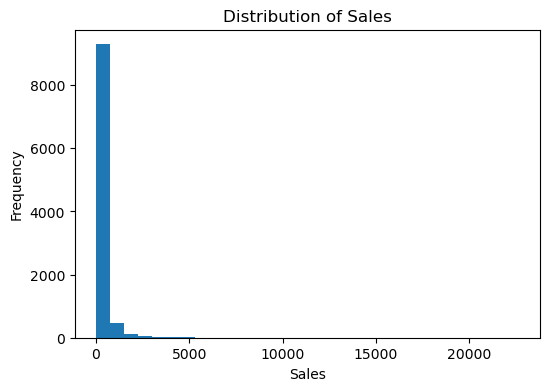

In [85]:
plt.figure(figsize=(6,4))
plt.hist(df["Sales"], bins=30)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

The sales distribution is positively skewed, meaning most transactions involve relatively low sales amounts, while a small number of transactions account for very high sales values. This suggests that revenue is driven by a limited number of large-value purchases.

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["Profit"], bins=30)
plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

The profit distribution shows both positive and negative values. While most transactions are profitable, there are several transactions resulting in losses. The spread also indicates high variability in profit margins.

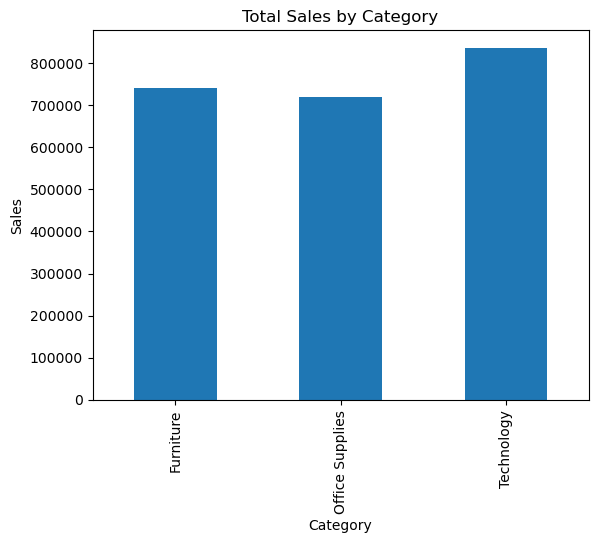

In [89]:
category_sales.plot(kind="bar")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

The Technology category generates the highest total sales compared to Furniture and Office Supplies. This indicates strong customer demand for technology products.

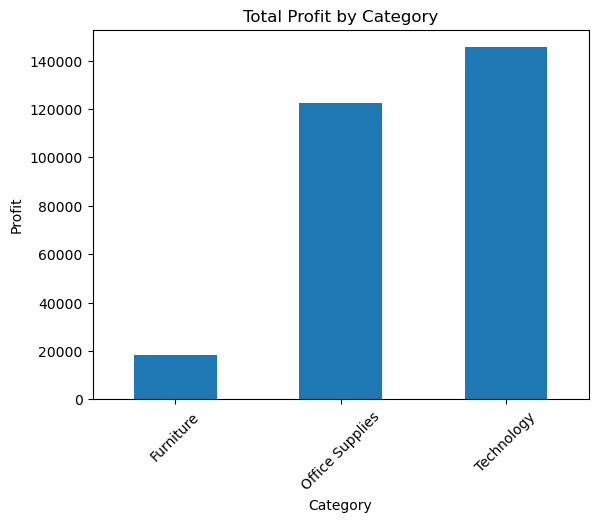

In [96]:
category_profit.plot(kind="bar")
plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

Although some categories generate high sales, their profit contribution may not be proportionally high. This indicates varying profit margins across categories.

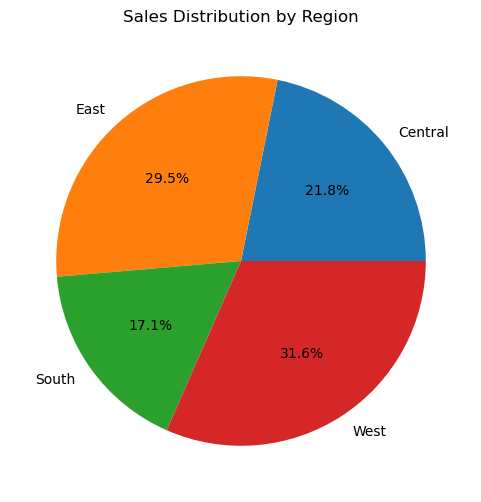

In [90]:
plt.figure(figsize=(6,6))
region_sales.plot(kind="pie", autopct="%1.1f%%")
plt.title("Sales Distribution by Region")
plt.ylabel("")
plt.show()

Certain regions contribute a larger percentage of total sales, indicating geographical differences in performance. However, a higher sales share does not necessarily guarantee higher profit.

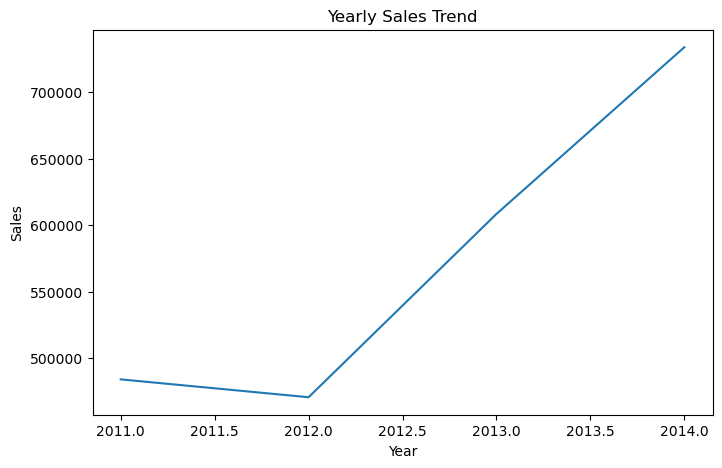

In [91]:
yearly_sales = df.groupby("Year")["Sales"].sum()

plt.figure(figsize=(8,5))
plt.plot(yearly_sales.index, yearly_sales.values)
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

The sales trend over the years shows fluctuations with periods of growth. An upward trend indicates business expansion, while dips may suggest seasonal or market-related challenges.

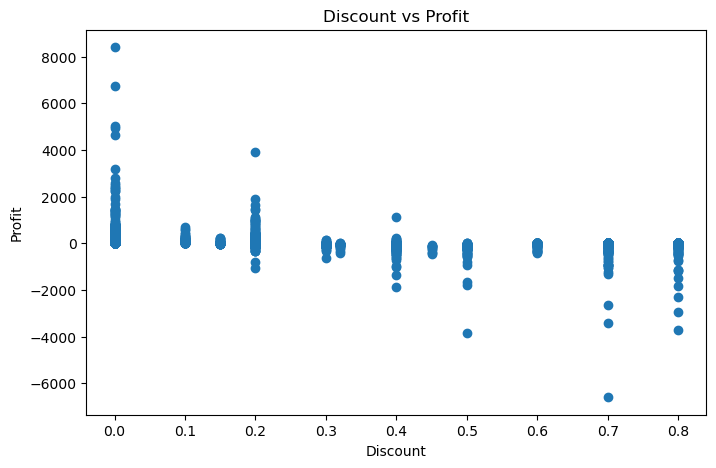

In [92]:
plt.figure(figsize=(8,5))
plt.scatter(df["Discount"], df["Profit"])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

There is a visible negative relationship between discount and profit. Higher discounts tend to reduce profitability, and extreme discounts often result in losses.

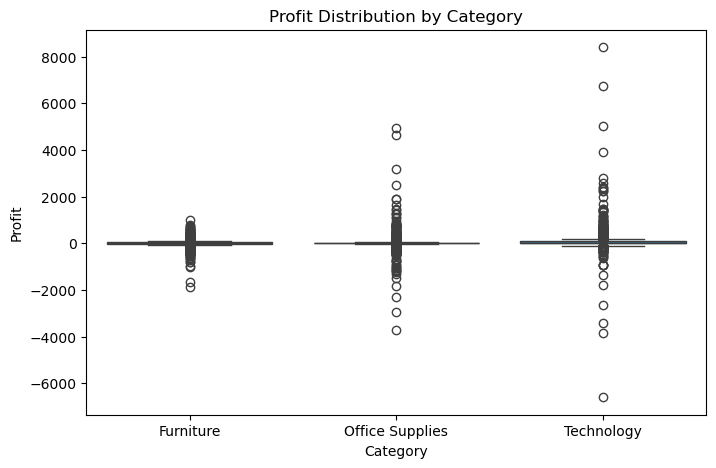

In [93]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Category", y="Profit", data=df)
plt.title("Profit Distribution by Category")
plt.show()

The boxplot reveals variability in profit distribution across categories. Some categories show wider spreads and more outliers, indicating inconsistent profitability.

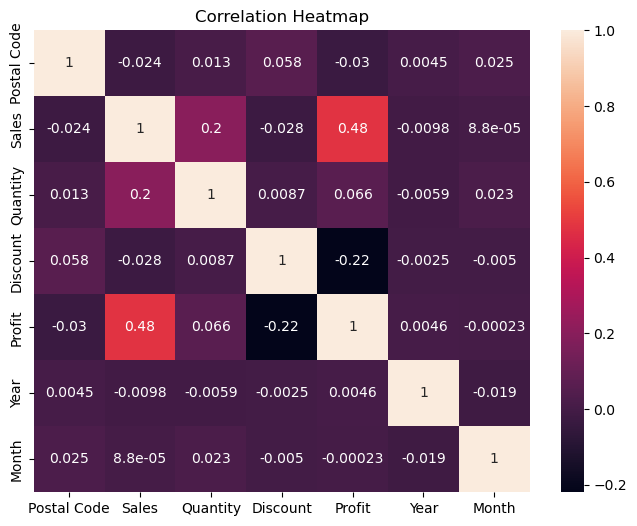

In [94]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True)
plt.title("Correlation Heatmap")
plt.show()

--Sales and Profit show a positive correlation, meaning higher sales generally result in higher profit.

--Discount and Profit show a negative correlation, confirming that increased discounting reduces profitability.

--Quantity may have moderate correlation with Sales but not necessarily with Profit.

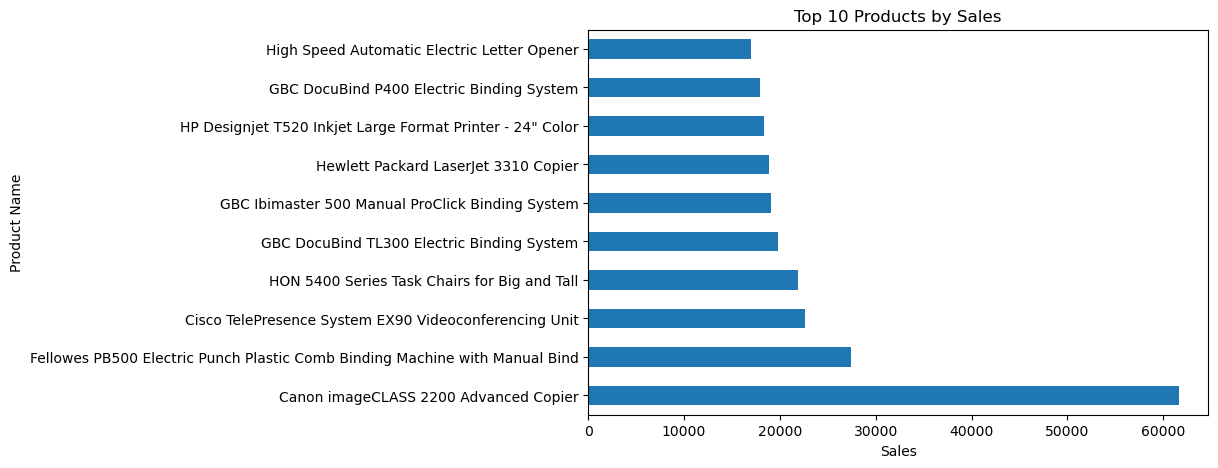

In [95]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_products.plot(kind="barh")
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.show()

A small number of products contribute significantly to total sales. These top-performing products act as key revenue drivers for the business.

        --OVERALL INSIGHTS--

--Revenue is concentrated in a small number of high-value transactions.

--Excessive discounting reduces profit significantly.

--Technology products are the strongest revenue driver.

--Regional performance varies significantly.

--Some sub-categories are unstable in profitability.

--Sales growth shows time-based patterns.

--High sales do not always guarantee high profit.